# 02 – EDA & Feature Engineering

This notebook loads the parsed log DataFrame, performs exploratory data analysis, engineers per-IP/per-hour features, and saves `data/processed/features.parquet`.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd().parent
sys.path.insert(0, str(ROOT))
import warnings; warnings.filterwarnings("ignore")


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PARSED = ROOT / "data" / "processed" / "parsed_logs.parquet"
df = pd.read_parquet(str(PARSED))
print(f"Loaded {len(df):,} rows.")
df.head(3)


Loaded 760 rows.


,ip_address,timestamp,method,endpoint,protocol,status_code,bytes_sent,referer,user_agent
0,192.168.99.1,2024-01-15 03:00:07+00:00,POST,/login,HTTP/1.1,403,292,-,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...
1,192.168.99.1,2024-01-15 03:00:26+00:00,POST,/login,HTTP/1.1,403,56,-,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...
2,192.168.99.1,2024-01-15 03:00:48+00:00,POST,/login,HTTP/1.1,401,249,-,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...


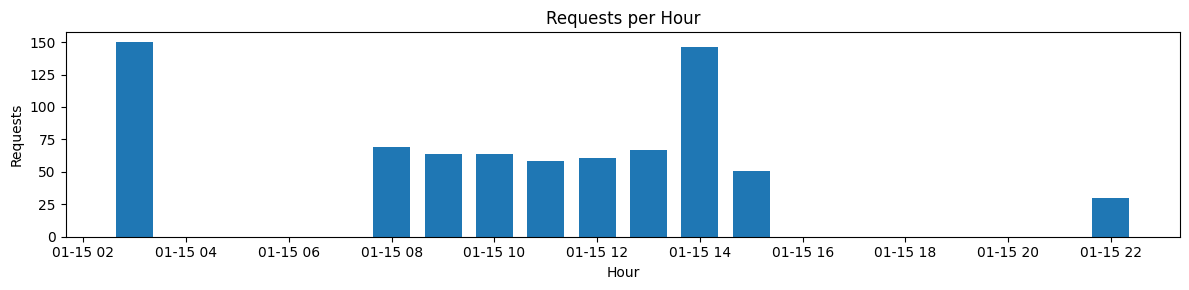

In [3]:
# ── EDA: request volume over time ────────────────────────────────────────────
df["hour"] = df["timestamp"].dt.floor("h")
hourly = df.groupby("hour").size().reset_index(name="count")

fig, ax = plt.subplots(figsize=(12, 3))
ax.bar(hourly["hour"], hourly["count"], width=0.03)
ax.set_xlabel("Hour"); ax.set_ylabel("Requests"); ax.set_title("Requests per Hour")
plt.tight_layout(); plt.show()


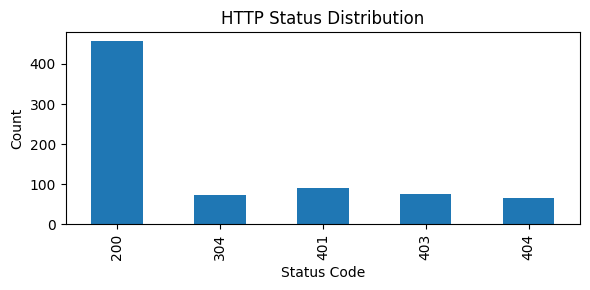

In [4]:
# ── EDA: status code distribution ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 3))
df["status_code"].value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_xlabel("Status Code"); ax.set_ylabel("Count"); ax.set_title("HTTP Status Distribution")
plt.tight_layout(); plt.show()


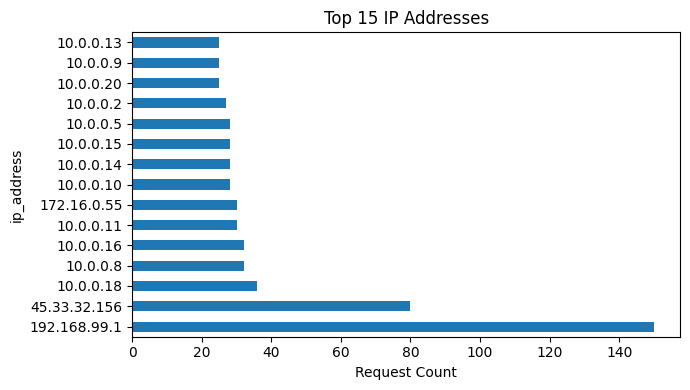

In [5]:
# ── EDA: top IPs ─────────────────────────────────────────────────────────────
top_ips = df["ip_address"].value_counts().head(15)
fig, ax = plt.subplots(figsize=(7, 4))
top_ips.plot(kind="barh", ax=ax)
ax.set_xlabel("Request Count"); ax.set_title("Top 15 IP Addresses")
plt.tight_layout(); plt.show()


In [6]:
# ── Feature engineering ───────────────────────────────────────────────────────
from pipeline.feature_engineering import engineer_features

feat_df = engineer_features(df)
print(f"Feature matrix: {feat_df.shape}")
feat_df.head()


Feature matrix: (159, 10)


,ip_address,hour_bucket,requests_per_hour,error_rate,unique_endpoints,avg_bytes_sent,post_ratio,is_off_hours,is_weekend,has_scanner_ua
0,10.0.0.1,2024-01-15 08:00:00+00:00,2,0.000000,2,4717.5,0.500000,0,0,0
1,10.0.0.1,2024-01-15 09:00:00+00:00,1,0.000000,1,4701.0,0.000000,0,0,0
2,10.0.0.1,2024-01-15 10:00:00+00:00,1,0.000000,1,2846.0,0.000000,0,0,0
3,10.0.0.1,2024-01-15 11:00:00+00:00,1,0.000000,1,2436.0,0.000000,0,0,0
4,10.0.0.1,2024-01-15 12:00:00+00:00,6,0.333333,5,2688.0,0.166667,0,0,0


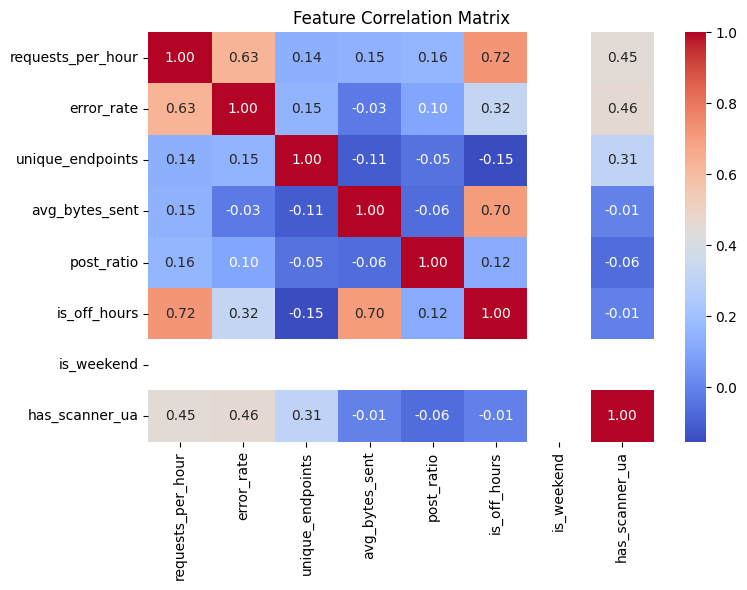

In [7]:
# ── Feature correlation heatmap ───────────────────────────────────────────────
FEAT_COLS = [
    "requests_per_hour", "error_rate", "unique_endpoints",
    "avg_bytes_sent", "post_ratio", "is_off_hours", "is_weekend", "has_scanner_ua"
]
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(feat_df[FEAT_COLS].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout(); plt.show()


In [8]:
# ── Save features ─────────────────────────────────────────────────────────────
OUT = ROOT / "data" / "processed" / "features.parquet"
feat_df.to_parquet(str(OUT), index=False)
print(f"Saved → {OUT}  ({len(feat_df):,} rows)")
feat_df[FEAT_COLS].describe().round(3)


Saved → /home/runner/work/log/log/data/processed/features.parquet  (159 rows)


,requests_per_hour,error_rate,unique_endpoints,avg_bytes_sent,post_ratio,is_off_hours,is_weekend,has_scanner_ua
count,159.000,159.000,159.000,159.000,159.000,159.000,159.0,159.000
mean,4.780,0.048,2.824,10982.980,0.213,0.013,0.0,0.006
std,13.359,0.147,1.353,105593.225,0.269,0.112,0.0,0.079
min,1.000,0.000,1.000,168.860,0.000,0.000,0.0,0.000
25%,2.000,0.000,2.000,1890.429,0.000,0.000,0.0,0.000
50%,3.000,0.000,3.000,2631.333,0.000,0.000,0.0,0.000
75%,4.000,0.000,4.000,3236.000,0.333,0.000,0.0,0.000
max,150.000,0.933,8.000,1334030.667,1.000,1.000,0.0,1.000
